# ANN benchmark 

In [1]:
# install 
%pip install numpy tensorflow matplotlib pandas seaborn scikit-learn

  Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.4-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached wrapt-1.17.2-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
  Using cached grpcio-1.71.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.meta

In [2]:
# imports

import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
import matplotlib.pyplot as plt

2025-03-26 17:46:41.995381: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 17:46:41.996938: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-26 17:46:42.001281: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-26 17:46:42.015883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743011202.036134 3257820 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743011202.04

In [3]:
# hyper paramaters

BATCH_SIZE = 30024
EPOCHS = 10
VERBOSE = 1
OPTIMIZER = Adam(0.0005)
NB_CLASSES = 1

2025-03-26 17:46:47.378973: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Model defintion:

In [4]:
def create_model(input_shape):
    model = Sequential([
        layers.Dense(512, input_shape=(input_shape,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64),
        layers.BatchNormalization(),
        
        layers.Dense(NB_CLASSES, activation='sigmoid')
    ])

    return model

# Load datasets

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


df_chall = pd.read_csv('../datasets/challenger_dataset.csv')
df_grandMaster = pd.read_csv('../datasets/grandmaster_dataset.csv')
df_master = pd.read_csv('../datasets/master_dataset.csv')

df = pd.concat([df_chall, df_grandMaster, df_master])

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

temp = df["timestamp"]
df.drop(columns=["timestamp"], inplace=True)
df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

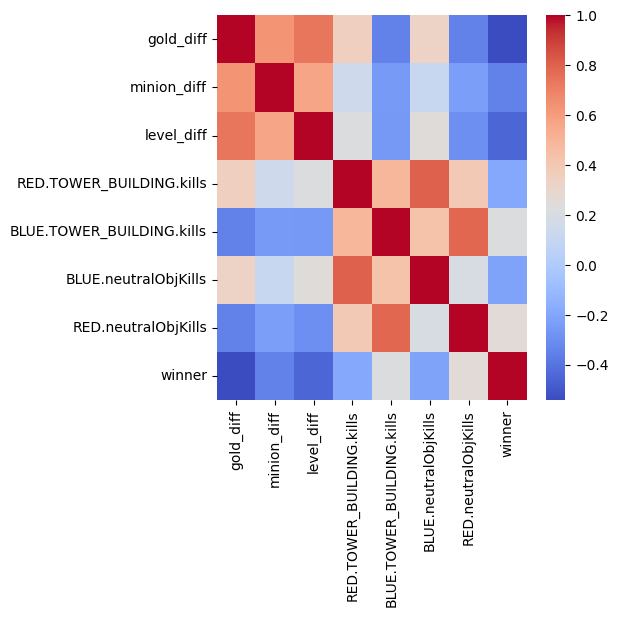

In [6]:
#trying to modify the dataset 
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']
# tdf["timestamp"] = temp

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [7]:
# split the dataset into training and testing
from sklearn.model_selection import train_test_split

X = tdf.drop('winner', axis=1)
y = tdf['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4840955, 7) (1210239, 7) (4840955,) (1210239,)


# Train the model

In [8]:
# create the model
model = create_model(len(X.columns))
model.compile(optimizer=OPTIMIZER, loss='binary_crossentropy', metrics=["accuracy"])
model.summary()

/home/youngsnow/Documents/UniversityKent/AISystemImpl/LeagueOfLegendsModelBenchmark/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/youngsnow/Documents/UniversityKent/AISystemImpl/LeagueOfLegendsModelBenchmark/venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,095,553 (4.18 MB)

 Trainable params: 1,091,329 (4.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [9]:
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

# train the model
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=VERBOSE, validation_split=0.2)

# evaluate the model
score = model.evaluate(X_test, y_test, verbose=VERBOSE)
print("Test score:", score[0])
print("Test accuracy:", score[1])

y_pred = model.predict(X_test)
y_pred = np.round(y_pred)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.6993 - loss: 0.5810 - val_accuracy: 0.7200 - val_loss: 0.6404
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.7389 - loss: 0.4985 - val_accuracy: 0.7321 - val_loss: 0.6100
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.7408 - loss: 0.4952 - val_accuracy: 0.7405 - val_loss: 0.5692
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.7408 - loss: 0.4950 - val_accuracy: 0.7413 - val_loss: 0.5261
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.7416 - loss: 0.4937 - val_accuracy: 0.7415 - val_loss: 0.4987
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.7415 - loss: 0.4931 - val_accuracy: 0.7410 - val_loss: 0.4928
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.7417 - loss: 0.4934 - val_accuracy: 0.7417 - val_loss: 0.4918
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7420 - loss: 0.4929 - val_accu

In [14]:
# f1 score
f1 = f1_score(y_test, y_pred)
print("F1 score:", f1)

# recall
recall = recall_score(y_test, y_pred)
print("Recall score:", recall)

# AUC-Roc
roc = roc_auc_score(y_test, y_pred)
print("AUC-ROC score:", roc)

# Brier score
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_pred)
print("Brier score:", brier)

# precision
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision score:", precision)

F1 score: 0.7297215286447496
Recall score: 0.7078283363439731
AUC-ROC score: 0.7418130963507026
Brier score: 0.25759374801175633
Precision score: 0.7530122637694541


6719/6719 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5175 - loss: 0.6939
5926/5926 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5284 - loss: 0.6927
4578/4578 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5620 - loss: 0.6828
5059/5059 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6019 - loss: 0.6624
5921/5921 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6263 - loss: 0.6441
6428/6428 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6446 - loss: 0.6307
6794/6794 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.6639 - loss: 0.6129
6979/6979 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.6819 - loss: 0.5930
7088/7088 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.6958 - loss: 0.5749
7147/7147 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.7106 - loss: 0.5565
7177/7177 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7252 - loss: 0.5382
7191/7191 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7393 - loss: 0.5192
7199/7199 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.7534 - lo

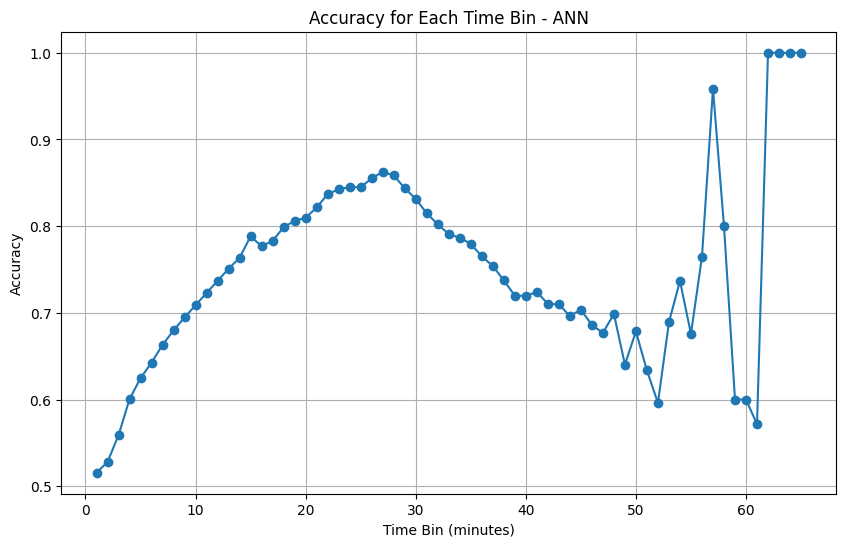

In [11]:
tdf["time_bin"] = (temp // 60000) * 60000

def predict_ann(model, X_test, y_test):
    pred = model.evaluate(X_test, y_test)
    return pred[1]

def plot_accuracy_over_time(model, label, df, prediction):
    minutes = []
    accuracies = []
    for time_bin, df_bin in df.groupby("time_bin"):
        minutes.append(time_bin // 60000)
        X_test_bin = df_bin.drop(columns=["winner", "time_bin"])
        y_test_bin = df_bin["winner"]
        accuracies.append(prediction(model, X_test_bin, y_test_bin))

    plt.figure(figsize=(10, 6))
    plt.plot(minutes, accuracies, marker='o', linestyle='-')
    plt.title(f'Accuracy for Each Time Bin - {label}')
    plt.xlabel('Time Bin (minutes)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_over_time(model, "ANN", tdf, predict_ann)

we can see that the accuracy greatly varies depending on the state of the game, which allow us to make some conclusion:
- first, the first 2 minutes have a close to random accuracy because it's in this range that remaking a game is still possible, making the dataset "poluted" with this game and also because, obviously, the first few minutes of a lol games aren't decisive on it's outcome
- then we can see the accuracy slowly increasing until the 30th minutes, were most games end. This is pretty logical since the difference between the two teams is, in most game, only getting bigger which make the team winning get an even bigger advantage with drakes, barons tower, and so on.
- after that we can see the accuracy of our model disminishin, this is because around this time, the team that is ahead is likely full stuff and max level, meaning they can't get any stronger, and that the loosing team is catching.

after the 40 minutes, the data is irelevant because of the amount of games being to small to not be overfitted

We can also see an outlier around the 14th minute, this is probably due to the herald spawning getting and great advantage especially if the void grubs are killed by the same team before, it gives a big gold lead by allowing the team killing it to get one, two or more tower early in the game giving them map control and economy.